In [1]:
import polars as pl

pdb_af3 = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet")
pdb_boltz = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.boltz_rmsd.parquet")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch


def plot_rmsd_bars(
    pdb_df: pl.DataFrame, inf_type: str, title: str | None = None
) -> plt.Figure:
    n = pdb_df.height

    replic_means = (
        pdb_df.filter(pl.col("replication"))
        .select(
            pl.col(f"peptide_rmsd_{inf_type}_4"),
            pl.col(f"mhc_rmsd_{inf_type}_4"),
            pl.col(f"tcr_rmsd_{inf_type}_4"),
            pl.col(f"cdr_rmsd_{inf_type}_4"),
        )
        .to_numpy()
    )
    post_means = (
        pdb_df.filter(~pl.col("replication"))
        .select(
            pl.col(f"peptide_rmsd_{inf_type}_4"),
            pl.col(f"mhc_rmsd_{inf_type}_4"),
            pl.col(f"tcr_rmsd_{inf_type}_4"),
            pl.col(f"cdr_rmsd_{inf_type}_4"),
        )
        .to_numpy()
    )

    labels = ["Peptide RMSD", "MHC RMSD", "TCR RMSD", "CDR RMSD"]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    # ax.text(
    #     0.01,
    #     0.95,
    #     f"n={n} triads",
    #     transform=ax.transAxes,
    #     verticalalignment="top",
    #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    # )

    # pre-training boxplots (blue)
    ax.boxplot(
        replic_means,
        positions=x - width / 2,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )

    # post-training boxplots (orange)
    ax.boxplot(
        post_means,
        positions=x + width / 2,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")

    # y-axis label
    ax.set_ylabel(f"RMSD between true and crystal structure (Å) {inf_type.upper()}")

    if title:
        ax.set_title(title)

    pre_patch = Patch(
        facecolor="tab:blue",
        edgecolor="black",
        label=f"Pre-training (n={replic_means.shape[0]})",
    )
    post_patch = Patch(
        facecolor="tab:orange",
        edgecolor="black",
        label=f"Post-training (n={post_means.shape[0]})",
    )
    ax.legend(handles=[pre_patch, post_patch], loc="upper right")

    plt.tight_layout()
    return fig

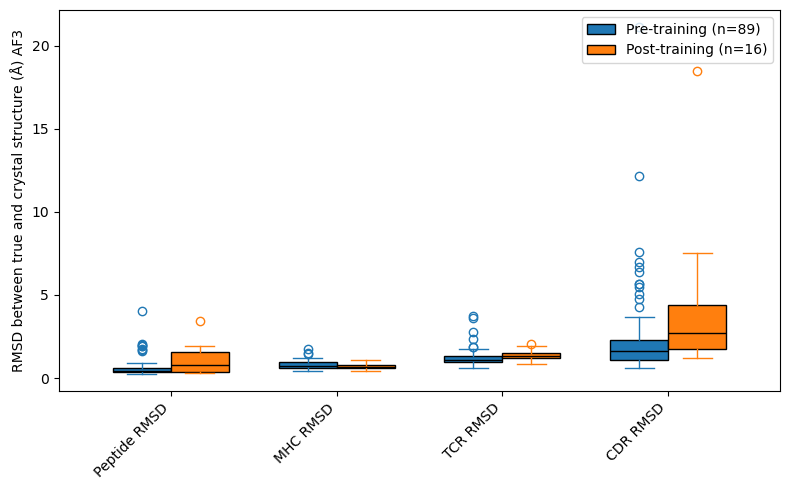

In [25]:
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3")

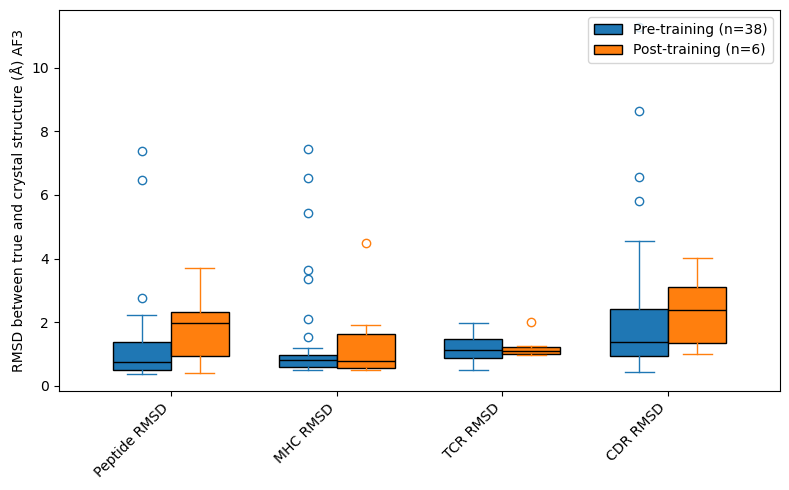

In [3]:
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "II"), "af3")

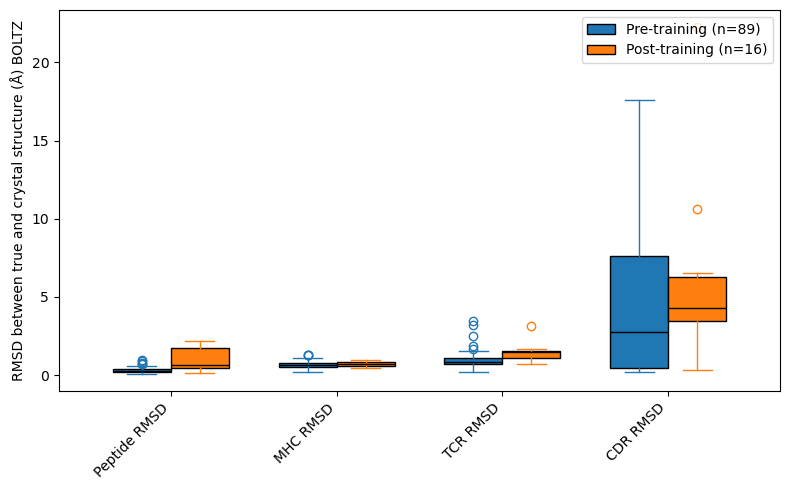

In [5]:
fig = plot_rmsd_bars(pdb_boltz.filter(pl.col("mhc_class") == "I"), "boltz")

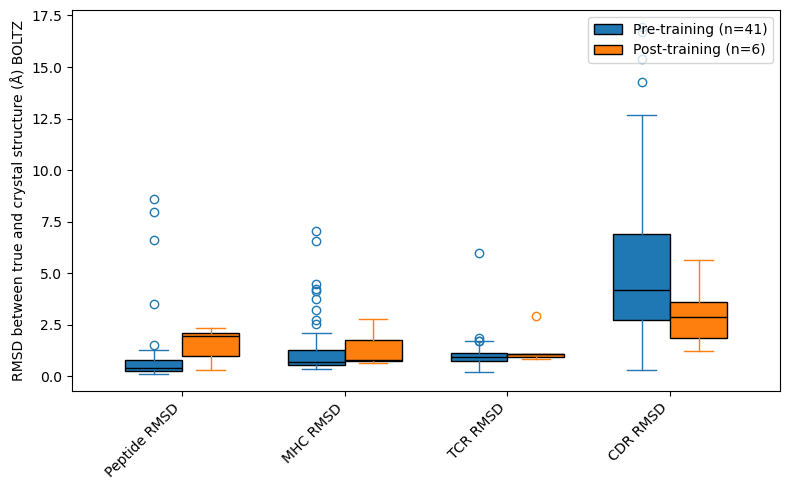

In [6]:
fig = plot_rmsd_bars(pdb_boltz.filter(pl.col("mhc_class") == "II"), "boltz")

In [8]:
pdb_af3.sort(by="mhc_rmsd_af3_4", descending=True)

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pdb,pdb_date,replication,peptide_segid,mhc_1_segid,mhc_2_segid,tcr_1_segid,tcr_2_segid,cdr_rmsd,cdr_rmsd_af2_full,cdr_rmsd_af2_trim,…,pred_mhc_axes_3,pred_mhc_origin_3,pred_tcr_axes_3,pred_tcr_origin_3,pred_dgeom_3,pred_sample_rank_3,pred_mhc_axes_4,pred_mhc_origin_4,pred_tcr_axes_4,pred_tcr_origin_4,pred_dgeom_4,pred_sample_rank_4,docking_rmsd_af3_0,cdr_rmsd_af3_0,peptide_rmsd_af3_0,mhc_rmsd_af3_0,tcr_rmsd_af3_0,docking_rmsd_af3_1,cdr_rmsd_af3_1,peptide_rmsd_af3_1,mhc_rmsd_af3_1,tcr_rmsd_af3_1,docking_rmsd_af3_2,cdr_rmsd_af3_2,peptide_rmsd_af3_2,mhc_rmsd_af3_2,tcr_rmsd_af3_2,docking_rmsd_af3_3,cdr_rmsd_af3_3,peptide_rmsd_af3_3,mhc_rmsd_af3_3,tcr_rmsd_af3_3,docking_rmsd_af3_4,cdr_rmsd_af3_4,peptide_rmsd_af3_4,mhc_rmsd_af3_4,tcr_rmsd_af3_4
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,"datetime[μs, UTC]",bool,str,str,str,str,str,f64,f64,f64,…,list[list[f64]],list[f64],list[list[f64]],list[f64],struct[8],i64,list[list[f64]],list[f64],list[list[f64]],list[f64],struct[8],i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""96b9104ef308fef91dbb9bea88fb6c…",true,"""FSWGAEGQRPGFGS""","""II""","""alpha""","""human""","""DRA*01:01""","""IKEEHVIIQAEFYLNPDQSGEFMFDFDGDE…","""beta""","""human""","""DRB1*04:01""","""GGGSLVPRGSGGGGSGDTRPRFLEQVKHEC…","""alpha""","""human""","""GDAKTTQPNSMESNEEEPVHLPCNHSTISG…","""beta""","""human""","""VVSQHPSWVIAKSGTSVKIECRSLDFQATT…","""TISGTDY""","""GLTSN""","""AEDRKS""","""CTVYGGATNKLIF""","""DFQATT""","""SNEGSKA""","""ASLTL""","""CSARGGSYNSPLHF""","""3o6f""",2011-03-02 00:00:00 UTC,true,"""B""","""A""","""B""","""C""","""D""",3.93,2.68,1.9,…,"[[0.251232, -0.847785, -0.467058], [0.928468, 0.34745, -0.13125], [0.273551, -0.400674, 0.874431]]","[-2.220167, 13.227749, 11.990749]","[[-0.048922, 0.839303, 0.541459], [0.119459, 0.543134, -0.831105], [-0.991633, 0.024023, -0.126834]]","[3.440846, -9.793077, -1.745808]","{27.398878,false,0.014986,0.161482,false,-0.034293,-0.04523,3.559929}",4,"[[0.251232, -0.847785, -0.467058], [0.928468, 0.34745, -0.13125], [0.273551, -0.400674, 0.874431]]","[-2.220167, 13.227749, 11.990749]","[[-0.048922, 0.839303, 0.541459], [0.119459, 0.543134, -0.831105], [-0.991633, 0.024023, -0.126834]]","[3.440846, -9.793077, -1.745808]","{27.398878,false,0.014986,0.161482,false,-0.034293,-0.04523,3.559929}",4,1.711808,1.605619,1.5514,4.115779,1.417181,1.711808,1.605619,1.5514,4.115779,1.417181,1.711808,1.605619,1.5514,4.115779,1.417181,1.893878,2.133684,1.619239,7.433171,1.342841,1.893878,2.133684,1.619239,7.433171,1.342841
"""9848c57a2301ecc2bd85803640fc29…",true,"""ADSLSFFSSSIKR""","""II""","""alpha""","""mouse""","""H2-IEk""","""ADPIKEEHTIIQAEFYLLPDKRGEFMFDFD…","""beta""","""mouse""","""H2-IEk""","""GGGSLVPRGSGGGGSRPWFLEYCKSECHFY…","""alpha""","""mouse""","""ADPGRGDQVEQSPSALSLHEGTGSALRCNF…","""beta""","""mouse""","""ADPKVIQTPRYLVKGQGQKAKMRCIPEKGH…","""TTMRA""","""LASGT""","""NSKESY""","""CAALRATGGNNKLTF""","""KGHPV""","""FQNQEV""","""PSNSP""","""CASSLNWSQDTQYF""","""6bga""",2018-07-18 00:00:00 UTC,true,"""B""","""A""","""B""","""C""","""D""",2.46,2.0,2.28,…,"[[0.145874, 0.419718, 0.895856], [-0.725646, -0.570101, 0.385257], [0.672427, -0.706273, 0.221404]]","[-1.40025, -7.96025, -14.993668]","[[0.030082, -0.539357, -0.841539], [-0.88889, 0.370608, -0.269304], [0.457133, 0.756137, -0.46828]]","[3.953, 3.739962, 10.281808]","{28.361979,false,0.254885,0.019106,false,-0.028818,0.032868,3.476885}",2,"[[0.061423, 0.998068, 0.009365], [0.862643, -0.057804, 0.502499], [0.50207, -0.022786, -0.864527]]","[-0.5265, -16.277666, -4.0215]","[[0.031454, -0.974174, -0.223598], [-0.211891, -0.